# 4.1.2 Spectral Pollution in Top Forms (Appendix A.1.2)

Reproduces Table 4.4, Figures 4.3-4.5 and Tables A.1-A.4 of the thesis: the top-form
eigenproblem on the criss-cross mesh of $(0,\pi)^2$ for the FEEC formulations
$A(\mathcal{P}_p)$, $B(\mathcal{N}^{\mathrm{I}}_p)$, $B(\mathcal{N}^{\mathrm{II}}_p)$, their
shifted twins, and the pathological $\tilde{B}(\mathcal{P}_1) = [\mathcal{P}_1]^2 \times
\operatorname{div}[\mathcal{P}_1]^2$. Imports the shared module `pseudospectra_partial_schur.py`
(must sit next to this notebook). Run top to bottom in a kernel with Firedrake + SLEPc + MUMPS
(the figures use `text.usetex`, so a LaTeX installation is needed); figures are written to
`./figures`.


## Setup


Imports, figure directory, table formatter and the LaTeX-matched figure style.


In [1]:
from __future__ import annotations

import itertools
from dataclasses import dataclass, field
from pathlib import Path
from typing import Callable, Optional

import numpy as np
import pandas as pd
import scipy.sparse as sp
import scipy.sparse.linalg as spla
import scipy.linalg as sla
import matplotlib
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

from firedrake import *
from firedrake.function import PointEvaluator
from firedrake.pyplot import triplot, tripcolor

from petsc4py import PETSc
from slepc4py import SLEPc

# The epsilon-pseudospectrum machinery lives in its own module: it works on
# assembled PETSc matrices and knows nothing about the formulation, so the same
# code serves this benchmark and the 1-form baseline.
import pseudospectra_partial_schur as ps

# `from firedrake import *` shadows the standard-library `logging`; re-import it
# under another name and silence the one warning `triplot` provokes on every call.
import logging as stdlogging
stdlogging.getLogger("firedrake").addFilter(
    lambda record: "is empty. This is likely an error" not in record.getMessage())

FIGDIR = Path("figures"); FIGDIR.mkdir(exist_ok=True)

plt.rcParams.update({
    "font.family": "serif", "mathtext.fontset": "cm",
    "font.size": 11, "axes.titlesize": 11, "axes.labelsize": 11,
    "figure.dpi": 110, "savefig.bbox": "tight", "savefig.pad_inches": 0.02,
    "axes.linewidth": 0.6,
})

L_DOMAIN = np.pi          # Omega = (0, L)^2


# --- table rendering, without the jinja2 dependency of pandas' .style --------
def _cell(value, spec):
    if value is None:
        return "--"
    if isinstance(value, complex):
        return (f"{value.real:.5f}{value.imag:+.5f}i" if abs(value.imag) > 1e-10
                else spec.format(value.real))
    try:
        return "--" if not np.isfinite(value) else spec.format(value)
    except (TypeError, ValueError):
        return str(value)


def fmt_table(df, caption=None, default="{:.6f}", rules=(), row_rules=()):
    """Format a DataFrame for display.

    `rules` is a list of (column-name-substring, format spec); `row_rules` the
    same for index labels, and takes precedence -- tables here sometimes carry a
    condition-number *row* rather than a column.
    """
    def spec_for(key, table):
        name = " ".join(map(str, key)) if isinstance(key, tuple) else str(key)
        # Exact matches win over substring matches, so a rule keyed on a short
        # name cannot capture a longer column that happens to contain it.
        return next((spec for k, spec in table if k == name),
                    next((spec for k, spec in table if k in name), None))

    out = pd.DataFrame(
        {col: [_cell(v, spec_for(idx, row_rules) or spec_for(col, rules) or default)
               for idx, v in zip(df.index, df[col])]
         for col in df.columns}, index=df.index)
    if caption:
        display(Markdown(f"**{caption}**"))
    return out


# Figure geometry and font size for the LaTeX-matched panels.  Section 7.4's
# style cell re-derives these from the same two numbers; they are defined here
# as well because three plotting cells above it refer to them, and without that
# the notebook cannot be run from a clean kernel.
latex_textwidth_pt = 426.79135        # \the\textwidth of the thesis class
inches_per_pt = 1.0 / 72.27
fig_width = latex_textwidth_pt * inches_per_pt
fig_height = fig_width * 0.75
base_fontsize = 11


#: Style for the pseudospectrum panels.  Section 7.4 defines this again
#: as part of its style block; it is defined here too because two panels
#: above that point already use it.
PS_RC = {
    "figure.figsize": (fig_width, fig_height),
    
    # Match LaTeX fonts
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    
    # Match font sizes exactly
    "font.size": base_fontsize,
    "axes.titlesize": base_fontsize,
    "axes.labelsize": base_fontsize,
    "legend.fontsize": base_fontsize - 1, # Slightly smaller for legend
    "xtick.labelsize": base_fontsize - 2, # Smaller for tick marks
    "ytick.labelsize": base_fontsize - 2,
    
    # Refine line weights for a professional look
    "axes.linewidth": 0.8,
    "lines.linewidth": 1.2,
    "grid.linewidth": 0.5,
}


print(f"PETSc scalars: {PETSc.ScalarType.__name__}")

PETSc scalars: float64


Criss-cross mesh and the background fields $\beta_0$-$\beta_7$.


In [2]:
def crisscross_mesh(N, L=L_DOMAIN):
    r"""Criss-cross triangulation of $(0,L)^2$: $4N^2$ cells, $h = L/N$.

    `diagonal="crossed"` is Firedrake's spelling of the Union-Jack pattern -- it
    inserts a centre vertex in every grid square and cuts both diagonals.  The
    resulting mesh is symmetric under all eight symmetries of the square, which
    matters here: the spurious mode of Section 4.4 is a checkerboard pattern
    living on exactly this structure.
    """
    return SquareMesh(N, N, L, quadrilateral=False, diagonal="crossed")

In [3]:
@dataclass(frozen=True)
class Wind:
    """A named background field, built lazily on a given mesh."""
    key: str
    tex: str
    note: str
    potential: bool           # beta = grad(phi)?  -> real spectrum (King)
    sup: float                # ||beta||_Linf, used for the shift nu of Lemma 4
    _build: Callable

    def __call__(self, mesh, L=L_DOMAIN):
        return self._build(mesh, L)


def _centre(mesh, L):
    x, y = SpatialCoordinate(mesh)
    return x - Constant(L / 2), y - Constant(L / 2)


def _b3(mesh, L):
    r"""beta_3 = (psi_y, psi_x) with psi = sin 2x sin 2y.

    Curl-free -- psi_xx - psi_yy = 0 for this psi -- so it is the gradient of
    -cos 2x cos 2y and King's theorem applies; but psi_xy != 0, so unlike every
    other smooth field in the table it is *not* solenoidal.  Written through UFL
    derivatives of psi rather than expanded by hand, so the identity
    beta = (psi_y, psi_x) is visible in the code.
    """
    x, y = SpatialCoordinate(mesh)
    psi = sin(2 * x) * sin(2 * y)
    return as_vector([psi.dx(1), psi.dx(0)])


def _b5(mesh, L):
    r"""beta_5 = (x + y, x y): the only field here that is neither.

    curl = y - 1 and div = 1 + x, both non-zero on (0, L)^2, so neither King's
    theorem nor Zeldovich's applies -- and with ||beta||_inf = L sqrt(4 + L^2)
    it is by some way the strongest wind in the table.
    """
    x, y = SpatialCoordinate(mesh)
    return as_vector([x + y, x * y])


WINDS = {
    "b0": Wind("b0", r"$\beta=(0,0)$", "no wind", True, 0.0,
               lambda mesh, L: None),
    "b1": Wind("b1", r"$\beta=(1,1)$", "uniform potential field", True, np.sqrt(2),
               lambda mesh, L: as_vector([Constant(1.0), Constant(1.0)])),
    # ||beta_2||_inf = |(L, L)| = L*sqrt(2), attained at the far corner: beta_2 is
    # measured from the origin, not from the centre of the square.
    "b2": Wind("b2", r"$\beta=(x,\,-y)$", "linear strain", True,
               L_DOMAIN * np.sqrt(2),
               lambda mesh, L: as_vector([SpatialCoordinate(mesh)[0],
                                          -SpatialCoordinate(mesh)[1]])),
    # ||beta_3||_inf = 2, attained where sin 2x = +-1 and cos 2y = +-1.
    "b3": Wind("b3", r"$\beta=(\partial_y\psi,\ \partial_x\psi)$",
               r"$\psi=\sin 2x\,\sin 2y$; potential, not solenoidal", True, 2.0, _b3),
    "b4": Wind("b4", r"$\beta=(-\hat y,\ \hat x)$", "rigid rotation", False,
               np.pi / np.sqrt(2),
               lambda mesh, L: as_vector([-_centre(mesh, L)[1], _centre(mesh, L)[0]])),
    # ||beta_5||_inf = |(2L, L^2)| = L sqrt(4 + L^2), at the far corner.
    "b5": Wind("b5", r"$\beta=(x+y,\ xy)$", "neither potential nor solenoidal",
               False, L_DOMAIN * np.sqrt(4.0 + L_DOMAIN ** 2), _b5),
    # NB: matplotlib's mathtext has no \tfrac, and these labels go into figure
    # titles as well as into markdown -- keep them to the common subset.
    "b7": Wind("b7", r"$\beta=(\mathrm{sign}(y-\frac{\pi}{2}),\ 0)$",
               "Heaviside shear", False, 1.0,
               lambda mesh, L: as_vector(
                   [conditional(gt(SpatialCoordinate(mesh)[1], Constant(L / 2)),
                                1.0, -1.0), Constant(0.0)])),
}

# The structural claims of the table, measured rather than asserted: b2 and b3
# are curl-free and only b2 is divergence-free, while b5 is neither.  They are
# needed later --
# curl-free is what guarantees the real spectrum against which the pseudospectra
# are read, and the divergence is what separates the two panels.
_m = crisscross_mesh(32)
print(" field   ||curl beta||_L2   ||div beta||_L2   ||beta||_Linf  (registry)")
for _k in ("b2", "b3", "b5"):
    _b = WINDS[_k](_m)
    _sup = np.sqrt(float(np.max(assemble(interpolate(
        dot(_b, _b), FunctionSpace(_m, "DG", 0))).dat.data_ro)))
    print(f"  {_k}    {sqrt(assemble((_b[1].dx(0) - _b[0].dx(1))**2 * dx)):.3e}"
          f"          {sqrt(assemble((_b[0].dx(0) + _b[1].dx(1))**2 * dx)):.3e}"
          f"         {_sup:.4f}      ({WINDS[_k].sup:.4f})")


 field   ||curl beta||_L2   ||div beta||_L2   ||beta||_Linf  (registry)


  b2    0.000e+00          0.000e+00         4.3967      (4.4429)


  b3    0.000e+00          1.257e+01         1.9893      (2.0000)


  b5    3.366e+00          8.564e+00         11.4921      (11.6999)


Formulations: primal $A(CG)$, mixed $B/\sigma$(RT, BDM) and the restricted $\sigma$(P1-divP1) pencil.


In [4]:
def primal_pencil(mesh, degree=1, beta=None, eps=Constant(1.0), nu=0.0):
    r"""`A(CG)`: $\varepsilon(\nabla u,\nabla v) - (\beta u,\nabla v) = \lambda(u,v)$."""
    V = FunctionSpace(mesh, "CG", degree)
    u, v = TrialFunction(V), TestFunction(V)

    a = eps * inner(grad(u), grad(v)) * dx
    if beta is not None:
        a -= inner(u * beta, grad(v)) * dx        # iota^n_beta u  <->  u * beta
    if nu:
        a += Constant(nu) * inner(u, v) * dx

    bcs = [DirichletBC(V, Constant(0.0), "on_boundary")]
    # `weight=0.0` puts 0 (not 1) on the constrained diagonal of M, so the
    # boundary rows contribute eigenvalues at infinity rather than at lambda = 1.
    A = assemble(a, bcs=bcs).petscmat
    M = assemble(inner(u, v) * dx, bcs=bcs, weight=0.0).petscmat
    return A, M, V, None

In [5]:
def nu_min(beta_sup, eps, C=1.0):
    r"""The shift of Lemma 4: $\nu \ge 2C^2\|\beta\|_\infty^2/\varepsilon + 2$.

    Remark 1 gives $\|\iota^n_\beta u\|_{L^2}\le\|\beta\|_{L^\infty}\|u\|_{L^2}$ for
    top forms, so $C=1$ is admissible.
    """
    return 2.0 * C**2 * beta_sup**2 / float(eps) + 2.0


def mixed_pencil(mesh, family="RT", degree=1, beta=None, eps=Constant(1.0), nu=0.0):
    r"""`B(...)` / `σ(...)`: the total-flux saddle point on $\Sigma_h \times V_h$.

    `family` is "RT" (trimmed) or "BDM" (full); both pair with $\mathrm{DG}_{r-1}$,
    which is what makes $\mathrm{d}^{n-1}\Sigma_h = V_h$ exactly.  No boundary
    condition is applied anywhere: $u|_{\partial\Omega}=0$ is natural here.
    """
    W = FunctionSpace(mesh, family, degree) * FunctionSpace(mesh, "DG", degree - 1)
    (s, u) = TrialFunctions(W)
    (t, v) = TestFunctions(W)

    a = ((1 / eps) * inner(s, t) * dx          # (eps^-1 sigma, tau)
         - inner(u, div(t)) * dx               # -(u, d^{n-1} tau)
         + inner(div(s), v) * dx)              # +(d^{n-1} sigma, v)
    if beta is not None:
        a -= (1 / eps) * inner(u * beta, t) * dx   # -(eps^-1 iota_beta u, tau)
    if nu:
        a += Constant(nu) * inner(u, v) * dx       # the shift of Lemma 3

    # The mass form touches only the u block: M is singular by construction, and
    # the sigma block supplies dim(Sigma_h) eigenvalues at infinity.
    return assemble(a).petscmat, assemble(inner(u, v) * dx).petscmat, W, None

In [6]:
def crisscross_blocks(mesh, N, L=L_DOMAIN):
    """Group the 4N^2 cells into N^2 macro-squares; return (blocks, north_south).

    Cells are identified by their centroids, so nothing depends on Firedrake's
    internal cell ordering.  Within a macro-square the four sub-triangle
    centroids sit at the centre plus (+-h/3, 0) and (0, +-h/3), so |dy| > |dx|
    picks out the north/south pair.
    """
    W = VectorFunctionSpace(mesh, "DG", 0)
    centroid = Function(W).interpolate(SpatialCoordinate(mesh)).dat.data_ro
    h = L / N
    idx = np.clip(np.floor(centroid / h).astype(int), 0, N - 1)
    offset = centroid - (idx + 0.5) * h
    north_south = np.abs(offset[:, 1]) > np.abs(offset[:, 0])
    key = idx[:, 0] * N + idx[:, 1]
    blocks = np.argsort(key, kind="stable").reshape(N * N, 4)
    return blocks, north_south


def checkerboard_basis(mesh, N, L=L_DOMAIN):
    r"""Return (C, Z): a basis of $\mathrm{coker}(\operatorname{div})$ and of $V_h$.

    C : (4N^2, N^2)  the checkerboard modes, +1 on N/S and -1 on E/W per square
    Z : (4N^2, 3N^2) an orthonormal basis of their orthogonal complement, i.e. of
        $V_h = \operatorname{div}[P_1]^2$, built three vectors at a time:
        $(e_N-e_S)/\sqrt2$, $(e_E-e_W)/\sqrt2$ and $(e_N+e_S+e_E+e_W)/2$.
    """
    blocks, north_south = crisscross_blocks(mesh, N, L)
    ncell = 4 * N * N
    q = 1 / np.sqrt(2)

    rows, cols, vals = [], [], []
    for k, blk in enumerate(blocks):
        rows += list(blk); cols += [k] * 4
        vals += list(np.where(north_south[blk], 0.5, -0.5))
    C = sp.csr_matrix((vals, (rows, cols)), shape=(ncell, N * N))

    rows, cols, vals = [], [], []
    for k, blk in enumerate(blocks):
        ns, ew = blk[north_south[blk]], blk[~north_south[blk]]
        for j, (cells, v) in enumerate([(tuple(ns), (q, -q)),
                                        (tuple(ew), (q, -q)),
                                        (tuple(blk), (0.5,) * 4)]):
            rows += list(cells); cols += [3 * k + j] * len(cells); vals += list(v)
    Z = sp.csr_matrix((vals, (rows, cols)), shape=(ncell, 3 * N * N))
    return C, Z


def to_scipy(mat):
    """PETSc AIJ -> scipy CSR (serial)."""
    indptr, indices, data = mat.getValuesCSR()
    return sp.csr_matrix((data, indices, indptr), shape=mat.getSize())


def to_petsc(S):
    """scipy sparse -> PETSc AIJ; PETSc wants sorted column indices."""
    S = sp.csr_matrix(S); S.sort_indices()
    return PETSc.Mat().createAIJWithArrays(
        S.shape, (S.indptr.astype(PETSc.IntType),
                  S.indices.astype(PETSc.IntType), S.data))


def p1divp1_pencil(mesh, N, beta=None, eps=Constant(1.0), nu=0.0, degree=1):
    r"""`σ(P1–divP1)`: the same form on $\Sigma_h=[P_1]^2$, $V_h=\operatorname{div}\Sigma_h$.

    The blocks are assembled on $\Sigma_h\times\mathrm{DG}_0$ -- Firedrake happily
    assembles a form whose two arguments live in different spaces -- and the
    $\mathrm{DG}_0$ side is then restricted to $V_h$ by the orthonormal `Z`.
    Restricting rather than working in the whole of $\mathrm{DG}_0$ matters for
    the eigensolver: the cokernel would otherwise contribute $N^2$ eigenvalues at
    $\lambda = 0$, sitting the same distance from the shift as the physical ones.

    `degree` is accepted only so that the registry can call every builder the same
    way; this pair is defined at lowest order and has no degree to raise.
    """
    S = VectorFunctionSpace(mesh, "CG", 1)
    Q = FunctionSpace(mesh, "DG", 0)
    s, t = TrialFunction(S), TestFunction(S)
    u, v = TrialFunction(Q), TestFunction(Q)

    A_ss = to_scipy(assemble((1 / eps) * inner(s, t) * dx).petscmat)
    form_su = -inner(u, div(t)) * dx
    if beta is not None:
        form_su = form_su - (1 / eps) * inner(u * beta, t) * dx
    A_su = to_scipy(assemble(form_su).petscmat)             # rows Sigma, cols DG0
    A_us = to_scipy(assemble(inner(div(s), v) * dx).petscmat)
    M_uu = to_scipy(assemble(inner(u, v) * dx).petscmat)

    _, Z = checkerboard_basis(mesh, N)
    A_su, A_us = A_su @ Z, Z.T @ A_us
    A_uu = Z.T @ (nu * M_uu) @ Z
    M_uu = Z.T @ M_uu @ Z

    A = sp.bmat([[A_ss, A_su], [A_us, sp.csr_matrix(A_uu)]], format="csr")
    M = sp.bmat([[sp.csr_matrix(A_ss.shape), None],
                 [None, sp.csr_matrix(M_uu)]], format="csr")
    return to_petsc(A), to_petsc(M), (S, Q), Z

Shift-and-invert eigensolver, eigenfunction extraction, exact spectrum, matching and condition estimates.


In [7]:
EPS_OPTS = {
    "eps_gen_non_hermitian": None,       # generalised, non-Hermitian pencil
    "eps_type": "krylovschur",
    "eps_target_magnitude": None,        # order by |lambda - tau|
    "eps_tol": 1e-11,
    "eps_max_it": 5000,
    "st_type": "sinvert",                # (A - tau M)^{-1} M
    "st_ksp_type": "preonly",            # the LU *is* the solve
    "st_pc_type": "lu",
    "st_pc_factor_mat_solver_type": "mumps",
    "st_mat_mumps_icntl_14": 800,        # working-space headroom for pivoting
}
_prefix = itertools.count()

#: registry consumed by `solve_topform`
FORMS = {
    "A(CG)":       dict(build=lambda mesh, N, **kw: primal_pencil(mesh, **kw),
                        shift=False, kind="primal"),
    "B(RT)":       dict(build=lambda mesh, N, **kw: mixed_pencil(mesh, "RT", **kw),
                        shift=False, kind="mixed"),
    "B(BDM)":      dict(build=lambda mesh, N, **kw: mixed_pencil(mesh, "BDM", **kw),
                        shift=False, kind="mixed"),
    "s(RT)":       dict(build=lambda mesh, N, **kw: mixed_pencil(mesh, "RT", **kw),
                        shift=True, kind="mixed"),
    "s(BDM)":      dict(build=lambda mesh, N, **kw: mixed_pencil(mesh, "BDM", **kw),
                        shift=True, kind="mixed"),
    "s(P1-divP1)": dict(build=lambda mesh, N, **kw: p1divp1_pencil(mesh, N, **kw),
                        shift=True, kind="restricted"),
}
FEEC_FORMS = ["A(CG)", "B(RT)", "B(BDM)", "s(RT)", "s(BDM)"]


@dataclass
class Spectrum:
    values: np.ndarray          # eigenvalues, shifted back, sorted by (Re, |Im|)
    space: object               # the FunctionSpace(s) the eigenvectors live in
    restriction: object         # Z for the restricted pencil, else None
    size: int                   # pencil dimension
    meta: dict
    eps_obj: object = None
    index: np.ndarray = None    # SLEPc indices matching `values`
    kappa: dict = None          # condition estimates for the matrix ST factorised

    @property
    def real(self):
        return self.values.real

    @property
    def kappa1(self):
        r"""Normwise $\kappa_1(A-\sigma M)$ of the solve that produced this spectrum."""
        return None if self.kappa is None else self.kappa[r"Hager $\kappa_1$"]


#: every condition estimate produced in this notebook, for the tally in Section 8
KAPPA_LOG = []


def solve_topform(form="B(RT)", wind="b0", N=32, degree=1, Rm=1.0, n_eigs=100,
                  nev=None, tau=None, mesh=None, L=L_DOMAIN, cond=True):
    r"""Solve the top-form eigenproblem for one (formulation, wind, $R_m$, mesh).

    `tau` defaults to $1.9\varepsilon$, just below $\lambda_1 \ge 2\varepsilon$.  The
    shifted formulations carry $\nu$ from Lemma 4 and hand back $\tilde\lambda-\nu$,
    so the returned eigenvalues are directly comparable across all six rows of
    `FORMS`.

    Unless `cond=False`, the condition of the matrix that was actually factorised,
    $A - \sigma M$ with $\sigma = \tau + \nu$, is estimated and attached to the
    result.  It is cheap next to the eigensolve, and computing it here rather than
    on request means no table in this notebook can quietly omit it.
    """
    mesh = crisscross_mesh(N, L) if mesh is None else mesh
    eps = Constant(1.0 / Rm)
    w = WINDS[wind]
    beta = w(mesh, L)

    spec = FORMS[form]
    nu = nu_min(w.sup, 1.0 / Rm) if spec["shift"] else 0.0
    A, M, space, Z = spec["build"](mesh, N, degree=degree, beta=beta, eps=eps, nu=nu)

    tau = (1.9 / Rm) if tau is None else tau
    nev = nev or min(n_eigs + 20, A.getSize()[0] - 1)

    opts = dict(EPS_OPTS, eps_target=tau + nu,
                eps_ncv=min(2 * nev + 30, A.getSize()[0]))
    prefix = f"tf{next(_prefix)}_"
    db = PETSc.Options()
    for k, v in opts.items():
        db[prefix + k] = v
    solver = SLEPc.EPS().create(comm=A.getComm())
    solver.setOptionsPrefix(prefix)
    solver.setOperators(A, M)
    solver.setDimensions(nev=nev)
    solver.setFromOptions()
    solver.solve()
    for k in opts:
        db.delValue(prefix + k)

    found = []
    for i in range(solver.getConverged()):
        z = complex(solver.getEigenvalue(i))
        if np.isfinite(z) and abs(z) < 1e10:
            found.append((i, z - nu))          # undo the Lemma 4 shift
    found = [p for p in found if abs(p[1]) > 1e-9]
    found.sort(key=lambda p: (p[1].real, abs(p[1].imag)))
    found = found[:n_eigs]

    kappa = condition_estimates(A, M, tau + nu) if cond else None
    if kappa is not None:
        KAPPA_LOG.append(dict(form=form, wind=wind, N=N, Rm=Rm, sigma=tau + nu,
                              **kappa))

    return Spectrum(np.array([z for _, z in found]), space, Z, A.getSize()[0],
                    dict(form=form, wind=wind, N=N, degree=degree, Rm=Rm,
                         eps=1.0 / Rm, tau=tau, nu=nu, kind=spec["kind"],
                         nconv=solver.getConverged(),
                         reason=solver.getConvergedReason()),
                    eps_obj=solver, index=np.array([i for i, _ in found]),
                    kappa=kappa)


def eigenfunction(spectrum, k):
    """The scalar field $u$ of the k-th eigenmode, as a Firedrake Function."""
    solver = spectrum.eps_obj
    A, _ = solver.getOperators()
    vr, vi = A.createVecRight(), A.createVecRight()
    solver.getEigenvector(int(spectrum.index[k]), vr, vi)
    arr = np.asarray(vr.getArray())
    kind, space = spectrum.meta["kind"], spectrum.space

    if kind == "restricted":                   # P1-divP1: lift V_h back to DG0
        S, Q = space
        f = Function(Q)
        f.dat.data[:] = spectrum.restriction @ arr[S.dim():]
        return f

    f = Function(space)                        # primal CG, or mixed RT/BDM x DG
    with f.dat.vec_wo as fv:
        fv.setArray(arr[:fv.getLocalSize()])
    return f.subfunctions[1] if kind == "mixed" else f

In [8]:
def exact_spectrum(n, Rm=1.0, beta_sq=0.0, kmax=80):
    r"""$\varepsilon(m^2+n^2) + |\beta|^2/4\varepsilon$, $m,n\ge1$, with multiplicity."""
    eps = 1.0 / Rm
    vals = sorted(m * m + k * k for m in range(1, kmax) for k in range(1, kmax))
    return np.array(vals[:n], dtype=float) * eps + beta_sq / (4.0 * eps)


def match(test, reference, rtol=3e-3):
    """Greedy one-to-one matching of `test` against `reference`.

    Returns (matched, extra): `matched[i]` is the reference partner of `test[i]`
    (NaN where none), `extra` collects the test values left over.  Only the range
    covered by both is judged, so a shorter reference window cannot manufacture
    spurious values at the top end.
    """
    ref = list(reference)
    hi = max(abs(r) for r in ref) if ref else np.inf
    matched, extra = [], []
    for v in test:
        if abs(v) > hi:
            matched.append(np.nan); continue
        if not ref:
            extra.append(v); matched.append(np.nan); continue
        j = int(np.argmin([abs(r - v) for r in ref]))
        if abs(ref[j] - v) <= rtol * max(1.0, abs(v)):
            matched.append(ref.pop(j))
        else:
            extra.append(v); matched.append(np.nan)
    return np.array(matched), np.array(extra)

In [9]:
def shifted_matrix(A, M, sigma):
    r"""$S = A - \sigma M$: exactly the matrix the ST hands to MUMPS."""
    S = A.copy()
    # A and M generally have different sparsity (the constrained rows of A(CG)
    # carry a diagonal that M does not), so the pattern must be declared unequal.
    S.axpy(-sigma, M, structure=PETSc.Mat.Structure.DIFFERENT_NONZERO_PATTERN)
    return S


def mumps_cond1(S, icntl14=800):
    """MUMPS' own condition estimate, RINFOG(10), via a throw-away LU + solve.

    `setFactorSetUpSolverType()` builds the factor Mat *before* the numeric
    factorisation, which is the only moment at which ICNTL(11) can still be set.
    The error analysis itself is performed during the solve, so a dummy solve is
    required to populate RINFOG.
    """
    ksp = PETSc.KSP().create(comm=S.getComm())
    ksp.setOperators(S)
    ksp.setType("preonly")
    pc = ksp.getPC()
    pc.setType("lu")
    pc.setFactorSolverType("mumps")
    pc.setFactorSetUpSolverType()
    F = pc.getFactorMatrix()
    F.setMumpsIcntl(11, 1)            # 1 = full error analysis -> RINFOG(10), (11)
    F.setMumpsIcntl(14, icntl14)
    ksp.setUp()
    b, x = S.createVecLeft(), S.createVecRight()
    b.set(1.0)
    ksp.solve(b, x)
    cond, infog1 = F.getMumpsRinfog(10), F.getMumpsInfog(1)
    ksp.destroy()
    return cond, infog1


def hager_cond1(S):
    r"""Normwise $\kappa_1 = \|S\|_1\|S^{-1}\|_1$, both factors by `onenormest`."""
    Ssp = to_scipy(S).tocsc()
    lu = spla.splu(Ssp)
    n = Ssp.shape[0]
    inverse = spla.LinearOperator(
        (n, n), matvec=lu.solve, rmatvec=lambda v: lu.solve(v, trans="T"))
    return spla.onenormest(Ssp) * spla.onenormest(inverse)


def condition_estimates(A, M, sigma, exact=False):
    """Both estimates for $A-\\sigma M$ (plus dense truth when `exact`)."""
    S = shifted_matrix(A, M, sigma)
    cond, infog1 = mumps_cond1(S)
    out = {"MUMPS COND1": cond, r"Hager $\kappa_1$": hager_cond1(S),
           "INFOG(1)": infog1}
    if exact:
        dense = to_scipy(S).toarray()
        out[r"exact $\kappa_2$"] = np.linalg.cond(dense, 2)
        out[r"exact $\kappa_1$"] = np.linalg.cond(dense, 1)
    return out


def condition_of(spectrum, exact=False):
    """Condition estimates for the matrix that *this* solve actually factorised."""
    A, M = spectrum.eps_obj.getOperators()
    return condition_estimates(A, M, spectrum.meta["tau"] + spectrum.meta["nu"],
                               exact=exact)

Base run parameters ($N=64$, 100 eigenvalues) and the eigenspace-gap helpers used by the $\beta_4$ convergence study.


In [10]:
N_BASE, N_EIGS = 64, 100
mesh = crisscross_mesh(N_BASE)
ALL_FORMS = list(FORMS)

In [11]:
DX_HI = dx(metadata={"quadrature_degree": 10})
N_TRACK = 5           # eigenvalues followed individually

#: Exact eigenvalue clusters of the Dirichlet Laplacian on (0,pi)^2 covering the
#: first five eigenvalues, with the index pairs whose sin(mx)sin(ny) span each
#: eigenspace.  The lambda = 10 pair is carried whole rather than cut in half.
CLUSTERS = [(2.0, [(1, 1)]),
            (5.0, [(1, 2), (2, 1)]),
            (8.0, [(2, 2)]),
            (10.0, [(1, 3), (3, 1)])]


def exact_mode(mesh, m, n):
    """The Dirichlet eigenfunction u_mn = sin(mx) sin(ny)."""
    x, y = SpatialCoordinate(mesh)
    return sin(m * x) * sin(n * y)


def rates(h, e):
    """Observed order between consecutive refinement levels."""
    h, e = np.asarray(h, float), np.asarray(e, float)
    r = np.full(e.shape, np.nan)
    with np.errstate(divide="ignore", invalid="ignore"):
        r[1:] = np.log(e[:-1] / e[1:]) / np.log(h[:-1] / h[1:])
    return r


def assign(exact, computed):
    """Greedy one-to-one: the computed value nearest each exact eigenvalue.

    Needed because `s(P1-divP1)` interleaves spurious values with the genuine
    ones, so the j-th computed eigenvalue is not the approximation to the j-th
    exact one.
    """
    pool = list(computed)
    out = []
    for value in exact:
        j = int(np.argmin([abs(c - value) for c in pool]))
        out.append(pool.pop(j))
    return np.array(out)


def _whiten(G):
    """W with W^T G W = I, dropping numerically null directions.

    An eigendecomposition rather than a Cholesky: on coarse meshes the computed
    basis of a cluster can be close to rank deficient, where a Cholesky fails.
    """
    w, V = np.linalg.eigh(G)
    keep = w > w.max() * 1e-13
    return V[:, keep] / np.sqrt(w[keep])


def subspace_error(computed, exact):
    """Sine of the largest principal angle between two L2 subspaces (the gap).

    With orthonormalised bases the singular values of the cross-Gram matrix are
    the cosines of the principal angles, so the largest angle is set by the
    smallest singular value.
    """
    gram = lambda P, Q: np.array([[assemble(inner(a, b) * DX_HI) for b in Q]
                                  for a in P])
    Wc, We = _whiten(gram(computed, computed)), _whiten(gram(exact, exact))
    sv = np.linalg.svd(Wc.T @ gram(computed, exact) @ We, compute_uv=False)
    return float(np.sqrt(max(0.0, 1.0 - min(sv.min(), 1.0) ** 2)))


def convergence_study(form, levels, degree=1):
    """Eigenvalue errors for the first N_TRACK modes, and the eigenspace gaps."""
    exact = exact_spectrum(N_TRACK)
    rows_e, rows_f = [], []
    for N in levels:
        mesh = crisscross_mesh(N)
        res = solve_topform(form=form, wind="b0", N=N, mesh=mesh, degree=degree,
                            n_eigs=25, nev=40)
        lam = res.real
        got = assign(exact, lam)
        rows_e.append(dict(N=N, h=np.pi / N, dof=res.size,
                           **{f"$\\lambda_{{{j+1}}}$": abs(got[j] - exact[j]) / exact[j]
                              for j in range(N_TRACK)},
                           **{r"$\kappa_1$": res.kappa1}))

        row = dict(N=N, h=np.pi / N)
        for value, modes in CLUSTERS:
            idx = np.argsort(np.abs(lam - value))[:len(modes)]
            row[f"$\\lambda={value:g}$"] = subspace_error(
                [eigenfunction(res, int(i)) for i in idx],
                [exact_mode(mesh, m, n) for m, n in modes])
        row[r"$\kappa_1$"] = res.kappa1
        rows_f.append(row)
    return (pd.DataFrame(rows_e).set_index("N"),
            pd.DataFrame(rows_f).set_index("N"))


# CONV_LEVELS = (4, 8, 16, 24, 32)
# # Every formulation in the registry, so that the polluting pair is read
# # against all five FEEC discretisations and not just against two of them.
# CONV_FORMS = FEEC_FORMS + ["s(P1-divP1)"]
# conv_eig, conv_fun = {}, {}
# for f in CONV_FORMS:
#     conv_eig[f], conv_fun[f] = convergence_study(f, CONV_LEVELS)

## Table 4.4: Top-form eigenvalues with advection at Rm = 1 (β2)


All six formulations under $\beta_2=(x,-y)$ at $R_m = 1$, $N = 64$, $p = 3$ (the restricted pair has no
degree), 100 eigenvalues near $\tau = 1.9$; first 20 shown with the MUMPS COND1 estimate. Parameter re-run
of the $R_m = 10$ cell (`Rm = 10` -> `Rm = 1`); the thesis table uses the $A(CG)$, $B(RT)$ and
$\sigma$(P1-divP1) columns.


In [12]:
N_ADV = 64
mesh_adv = crisscross_mesh(N_ADV)

# For b2 (linear strain), we use the default shift (tau = 1.9).
# Because b2 is a gradient field, King's theorem guarantees a real spectrum.
runs_b2 = {f: solve_topform(form=f, wind="b2", N=N_ADV,degree=3, Rm = 1, mesh=mesh_adv, n_eigs=100)
           for f in ALL_FORMS}

# Since b2's spectrum is real to machine precision, standard sorting or 
# np.sort_complex will both work perfectly to align the formulations.
def ordered(spectrum, n=20):
    return np.sort_complex(np.asarray(spectrum.values))[:n]

# There is no closed-form exact spectrum for b2, so we rely on the FEEC columns
# to act as the reference.
tbl = pd.DataFrame({f: ordered(runs_b2[f], 20) for f in ALL_FORMS},
                   index=[f"$\\lambda_{{{i+1}}}$" for i in range(20)])

# Append the condition number using MUMPS COND1
tbl.loc["MUMPS COND1"] = [runs_b2[f].kappa["MUMPS COND1"] for f in ALL_FORMS]

fmt_table(tbl, row_rules=[("MUMPS COND1", "{:.2e}")],
          caption=rf"$\beta_2 = (x, -y)$, $R_m = 1$: linear strain. "
                  rf"No exact spectrum available; criss-cross $N={N_ADV}$")

**$\beta_2 = (x, -y)$, $R_m = 1$: linear strain. No exact spectrum available; criss-cross $N=64$**

,A(CG),B(RT),B(BDM),s(RT),s(BDM),s(P1-divP1)
$\lambda_{1}$,3.269549,3.269549,3.269549,3.269549,3.269549,3.269367
$\lambda_{2}$,6.440456,6.440456,6.440456,6.440456,6.440456,6.440141
$\lambda_{3}$,6.440456,6.440456,6.440456,6.440456,6.440456,6.440912
$\lambda_{4}$,9.611362,9.611362,9.611362,9.611362,9.611362,6.459349
$\lambda_{5}$,11.455017,11.455017,11.455017,11.455017,11.455017,9.612657
$\lambda_{6}$,11.455017,11.455017,11.455017,11.455017,11.455017,11.457076
$\lambda_{7}$,14.625924,14.625924,14.625924,14.625924,14.625924,11.459134
$\lambda_{8}$,14.625924,14.625924,14.625924,14.625924,14.625924,14.631097
$\lambda_{9}$,18.456898,18.456898,18.456898,18.456898,18.456898,14.632968
$\lambda_{10}$,18.456898,18.456898,18.456898,18.456898,18.456898,15.47742-0.00030i


## Figure 4.3: Convergence of the pathological B̃(P1) under β4


Reference solve $B(BDM)$, $p = 3$, $N = 32$ under $\beta_4$ (gives the targets $\lambda_1 = 2.003577$,
$\lambda_{2,3} = 5.023288 \pm 0.968152i$ hard-coded below) and the conjugate-pair helpers.


In [13]:
B4_REF_N, B4_REF_DEG, B4_FUN_DEG = 32, 3, 2

ref_b4 = solve_topform(form="B(BDM)", wind="b4", N=B4_REF_N, degree=B4_REF_DEG,
                       n_eigs=20)


def conj_clusters(values, n_groups=4, tol=1e-8):
    """Group a spectrum into its real invariant blocks: conjugate pairs merged.

    `np.sort_complex` orders by real part then imaginary part, so the two members
    of a conjugate pair are adjacent and a single forward pass is enough.
    """
    vals = list(np.sort_complex(np.asarray(values)))
    groups, i = [], 0
    while i < len(vals) and len(groups) < n_groups:
        if abs(vals[i].imag) <= tol:
            groups.append([vals[i]]); i += 1
        else:
            groups.append([vals[i], vals[i + 1]]); i += 2
    return groups


def eigenpair_parts(spectrum, k):
    r"""$(\mathrm{Re}\,v,\ \mathrm{Im}\,v)$ of the $k$-th mode, as two Functions.

    `eigenfunction` keeps only the real part, which is all a real spectrum needs.
    A conjugate pair in real arithmetic is stored by SLEPc as one $(v_r, v_i)$
    with both halves of comparable size, and the invariant subspace it spans is
    two-dimensional; discarding $v_i$ would collapse it to a line and make the
    gap meaningless.
    """
    solver = spectrum.eps_obj
    A, _ = solver.getOperators()
    vr, vi = A.createVecRight(), A.createVecRight()
    solver.getEigenvector(int(spectrum.index[k]), vr, vi)
    kind, space = spectrum.meta["kind"], spectrum.space
    parts = []
    for vec in (vr, vi):
        arr = np.asarray(vec.getArray())
        if kind == "restricted":                   # P1-divP1: lift V_h back to DG0
            S, Q = space
            f = Function(Q)
            f.dat.data[:] = spectrum.restriction @ arr[S.dim():]
        else:
            f = Function(space)
            with f.dat.vec_wo as fv:
                fv.setArray(arr[:fv.getLocalSize()])
            f = f.subfunctions[1] if kind == "mixed" else f
        parts.append(f)
    return parts


def cluster_modes(spectrum, group):
    """Real basis of the invariant subspace of `spectrum` nearest `group`."""
    z = max(group, key=lambda v: v.imag)           # the Im >= 0 representative
    k = int(np.argmin(np.abs(np.asarray(spectrum.values) - z)))
    re, im = eigenpair_parts(spectrum, k)
    return [re] if len(group) == 1 else [re, im]


B4_GROUPS = conj_clusters(ref_b4.values, n_groups=4)
B4_FUN_COLS = [f"$\\lambda\\approx{g[0].real:.5g}$" for g in B4_GROUPS]
B4_REF5 = np.sort_complex(np.asarray(ref_b4.values))[:N_TRACK]

print(f"reference: B(BDM) degree {B4_REF_DEG}, N = {B4_REF_N}, "
      f"kappa_1 = {ref_b4.kappa1:.2e}")
print(" first five:", np.round(B4_REF5, 7))
for g, c in zip(B4_GROUPS, B4_FUN_COLS):
    print(f"  cluster {c}: {'conjugate pair' if len(g) == 2 else 'simple, real'}"
          f"   dim {len(cluster_modes(ref_b4, g))}")

reference: B(BDM) degree 3, N = 32, kappa_1 = 1.19e+06
 first five: [2.0035774+0.j        5.0232879-0.9681517j 5.0232879+0.9681517j
 9.0251594-1.6895124j 9.0251594+1.6895124j]
  cluster $\lambda\approx2.0036$: simple, real   dim 1
  cluster $\lambda\approx5.0233$: conjugate pair   dim 2
  cluster $\lambda\approx9.0252$: conjugate pair   dim 2
  cluster $\lambda\approx10.099$: simple, real   dim 1


$h$-refinement of $\sigma$(P1-divP1) under $\beta_4$, $R_m = 1$, $p = 1$, $\tau = 1.9$,
$N \in \{8,12,16,24,32,40\}$, 40 eigenvalues per solve; eigenfunction gaps against $B(BDM)$ $p = 2$ on the same
mesh (spurious modes against $B(BDM)$ at $3\varepsilon$). Spurious targets $6.000253$, $14.99104 + 0.96067i$
are the $N = 64$ values of Table A.1. Writes `topform_spurious_convergence_b4.eps` and
`topform_spurious_eigenfunctions_b4.eps`.


Starting convergence study for beta_4...
Solving for N = 8...


Solving for N = 12...


Solving for N = 16...


Solving for N = 24...


Solving for N = 32...


Solving for N = 40...


Solves complete. Generating plots...


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


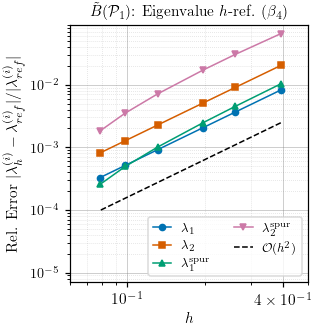

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


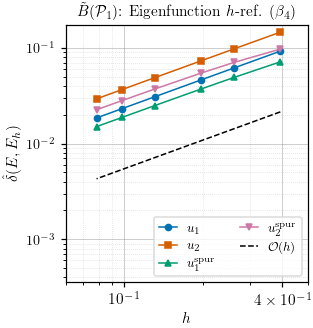

In [14]:
from matplotlib.ticker import LogLocator, NullFormatter

def crisscross_blocks(mesh, N, L=np.pi):
    """Group the 4N^2 cells into N^2 macro-squares."""
    W = VectorFunctionSpace(mesh, "DG", 0)
    centroid = Function(W).interpolate(SpatialCoordinate(mesh)).dat.data_ro
    h = L / N
    idx = np.clip(np.floor(centroid / h).astype(int), 0, N - 1)
    offset = centroid - (idx + 0.5) * h
    north_south = np.abs(offset[:, 1]) > np.abs(offset[:, 0])
    key = idx[:, 0] * N + idx[:, 1]
    blocks = np.argsort(key, kind="stable").reshape(N * N, 4)
    return blocks, north_south

def macro_sign(mesh, N, L=np.pi):
    r"""$c_h=(-1)^{i+j}$ on macro-square $(i,j)$, as a DG_0 Function."""
    blocks, _ = crisscross_blocks(mesh, N, L)
    f = Function(FunctionSpace(mesh, "DG", 0))
    d = np.empty(f.dat.data.shape)
    for k, blk in enumerate(blocks):
        d[blk] = (-1.0)**((k // N) + (k % N))
    f.dat.data[:] = d
    return f

def unsign(u, mesh, N):
    r"""$c_h \cdot u$: the shadow mode with its Nyquist sign pattern divided out."""
    out = Function(FunctionSpace(mesh, "DG", 0))
    out.dat.data[:] = (macro_sign(mesh, N).dat.data_ro * np.asarray(u.dat.data_ro))
    return out

    
# --- Data Extraction ---
LEVELS = (8, 12, 16, 24, 32, 40)
rows = []

# High-order reference targets for b4
t_g1 = 2.003577
t_g2 = 5.023288 + 0.968152j
t_s1 = 6.000253 
t_s2 = 14.99104 + 0.96067j

print("Starting convergence study for beta_4...")

for N in LEVELS:
    print(f"Solving for N = {N}...")
    mesh_c = crisscross_mesh(N)
    
    # 1. The polluting element
    s = solve_topform(form="s(P1-divP1)", wind="b4", N=N, mesh=mesh_c, n_eigs=40)
    v = s.values
    
    # Find nearest indices
    i_g1 = int(np.argmin(np.abs(v - t_g1)))
    i_g2 = int(np.argmin(np.abs(v - t_g2)))
    i_s1 = int(np.argmin(np.abs(v - t_s1)))
    i_s2 = int(np.argmin(np.abs(v - t_s2)))
    
    # Relative eigenvalue errors
    e_gen1 = np.abs(v[i_g1] - t_g1) / np.abs(t_g1)
    e_gen2 = np.abs(v[i_g2] - t_g2) / np.abs(t_g2)
    e_sp1  = np.abs(v[i_s1] - t_s1) / np.abs(t_s1)
    e_sp2  = np.abs(v[i_s2] - t_s2) / np.abs(t_s2)
    
    # 2. Eigenfunction references on the same mesh
    fine = solve_topform(form="B(BDM)", wind="b4", N=N, mesh=mesh_c, degree=2, n_eigs=40, cond=False)
    tri = solve_topform(form="B(BDM)", wind="b4", N=N, mesh=mesh_c, Rm=1/3, n_eigs=40, cond=False)
    
    # Subspace gaps (Genuine)
    gap_g1 = subspace_error(cluster_modes(s, [v[i_g1]]), cluster_modes(fine, [fine.values[int(np.argmin(np.abs(fine.values - t_g1)))]]))
    
    fine_g2_re, fine_g2_im = eigenpair_parts(fine, int(np.argmin(np.abs(fine.values - t_g2))))
    gap_g2 = subspace_error(cluster_modes(s, [v[i_g2], v[i_g2].conjugate()]), [fine_g2_re, fine_g2_im])
    
    # Subspace gaps (Spurious -> Unsign and compare to Rm=1/3 reference)
    env_s1 = unsign(eigenfunction(s, i_s1), mesh_c, N)
    tri_1 = eigenfunction(tri, int(np.argmin(np.abs(tri.values - t_s1))))
    gap_s1 = subspace_error([env_s1], [tri_1])
    
    re_s2, im_s2 = eigenpair_parts(s, i_s2)
    env_re_s2 = unsign(re_s2, mesh_c, N)
    env_im_s2 = unsign(im_s2, mesh_c, N)
    tri_re_2, tri_im_2 = eigenpair_parts(tri, int(np.argmin(np.abs(tri.values - t_s2))))
    gap_s2 = subspace_error([env_re_s2, env_im_s2], [tri_re_2, tri_im_2])
    
    rows.append(dict(N=N, h=np.pi/N, 
                     e_gen1=e_gen1, e_gen2=e_gen2, e_sp1=e_sp1, e_sp2=e_sp2,
                     e_g1_fun=gap_g1, e_g2_fun=gap_g2, e_s1_fun=gap_s1, e_s2_fun=gap_s2))

df = pd.DataFrame(rows)
h = df["h"].to_numpy()
print("Solves complete. Generating plots...")

# --- Plotting Configuration ---
half_width = fig_width * 0.49
half_height = half_width * 1.05 
colors = ['#0072B2', '#D55E00', '#009E73', '#CC79A7', '#E69F00']
sub_fontsize = base_fontsize - 1 

# --- 1. Eigenvalues Plot ---
with matplotlib.rc_context(PS_RC):
    fig, ax = plt.subplots(figsize=(half_width, half_height))

    ax.loglog(h, df["e_gen1"], marker="o", color=colors[0], ms=4.0, lw=1.0, label=r"$\lambda_1$")
    ax.loglog(h, df["e_gen2"], marker="s", color=colors[1], ms=4.0, lw=1.0, label=r"$\lambda_{2}$")
    ax.loglog(h, df["e_sp1"], marker="^", color=colors[2], ms=4.0, lw=1.0, label=r"$\lambda^{\mathrm{spur}}_1$")
    ax.loglog(h, df["e_sp2"], marker="v", color=colors[3], ms=4.0, lw=1.0, label=r"$\lambda^{\mathrm{spur}}_{2}$")

    ref = 0.30 * min(df["e_gen1"].iloc[0], df["e_gen2"].iloc[0], df["e_sp1"].iloc[0], df["e_sp2"].iloc[0])
    ax.loglog(h, ref * (h / h[0]) ** 2, "k--", lw=1.0, label=r"$\mathcal{O}(h^{2})$")

    ax.set_xlabel(r"$h$", fontsize=sub_fontsize)
    ax.set_ylabel(r"Rel. Error $|\lambda_h^{(i)} - \lambda_{ref}^{(i)}| / |\lambda_{ref}^{(i)}|$", fontsize=sub_fontsize)
    ax.set_title(r"$\tilde{B}(\mathcal{P}_1)$: Eigenvalue $h$-ref. ($\beta_4$)", fontsize=sub_fontsize)

    ax.grid(True, which="major", color="gray", linestyle="-", alpha=0.5, lw=0.5)
    # --- 1. Eigenvalues Plot ---
# ... (previous code)
    ax.grid(True, which="minor", color="gray", linestyle=":", alpha=0.3, lw=0.5)

    # --- Strict Axis Controls ---
    # Banish 10^0 by capping the right limit at 0.5 (max data is h=0.39)
    ax.set_xlim(left=0.06, right=0.5)
    
    # Explicitly enforce 10^-1 and the requested 0.4 (or 0.07 if preferred)
    ax.set_xticks([0.1, 0.4])
    ax.set_xticklabels([r"$10^{-1}$", r"$4\times 10^{-1}$"], fontsize=sub_fontsize)

    # Re-apply minor ticks, but omit '4' to prevent it drawing over our custom major tick
    locmin = LogLocator(base=10.0, subs=(2, 3, 5, 6, 7, 8, 9), numticks=12)
    ax.xaxis.set_minor_locator(locmin)
    ax.xaxis.set_minor_formatter(NullFormatter())

    ymin, ymax = ax.get_ylim()
    ax.set_ylim(bottom=ymin * 0.1) 
# ... (rest of the block) 

    ax.legend(fontsize=sub_fontsize - 2, frameon=True, edgecolor="lightgray", 
              ncol=2, loc="lower right", handlelength=1.5, borderpad=0.4)

    plt.tight_layout(pad=0.3)
    fig.savefig(FIGDIR / "topform_spurious_convergence_b4.eps")
    plt.show()

# --- 2. Eigenfunctions Plot ---
with matplotlib.rc_context(PS_RC):
    fig, ax = plt.subplots(figsize=(half_width, half_height))

    ax.loglog(h, df["e_g1_fun"], marker="o", color=colors[0], ms=4.0, lw=1.0, label=r"$u_1$")
    ax.loglog(h, df["e_g2_fun"], marker="s", color=colors[1], ms=4.0, lw=1.0, label=r"$u_2$")
    ax.loglog(h, df["e_s1_fun"], marker="^", color=colors[2], ms=4.0, lw=1.0, label=r"$u_{1}^{\mathrm{spur}}$")
    ax.loglog(h, df["e_s2_fun"], marker="v", color=colors[3], ms=4.0, lw=1.0, label=r"$u_{2}^{\mathrm{spur}}$")

    ref = 0.30 * min(df["e_g1_fun"].iloc[0], df["e_g2_fun"].iloc[0], df["e_s1_fun"].iloc[0], df["e_s2_fun"].iloc[0])
    ax.loglog(h, ref * (h / h[0]) ** 1, "k--", lw=1.0, label=r"$\mathcal{O}(h)$")

    ax.set_xlabel(r"$h$", fontsize=sub_fontsize)
    ax.set_ylabel(r"$\hat{\delta}(E, E_h)$", fontsize=sub_fontsize)
    ax.set_title(r"$\tilde{B}(\mathcal{P}_1)$: Eigenfunction $h$-ref. ($\beta_4$)", fontsize=sub_fontsize)

    ax.grid(True, which="major", color="gray", linestyle="-", alpha=0.5, lw=0.5)
    # --- 2. Eigenfunctions Plot ---
# ... (previous code)
    ax.grid(True, which="minor", color="gray", linestyle=":", alpha=0.3, lw=0.5)

    # --- Strict Axis Controls ---
    ax.set_xlim(left=0.06, right=0.5)
    
    ax.set_xticks([0.1, 0.4])
    ax.set_xticklabels([r"$10^{-1}$", r"$4\times 10^{-1}$"], fontsize=sub_fontsize)

    ax.xaxis.set_minor_locator(locmin)
    ax.xaxis.set_minor_formatter(NullFormatter())

    ymin, ymax = ax.get_ylim()
    ax.set_ylim(bottom=ymin * 0.1) 
# ... (rest of the block)

    ax.legend(fontsize=sub_fontsize - 2, frameon=True, edgecolor="lightgray", 
              ncol=2, loc="lower right", handlelength=1.5, borderpad=0.4)

    plt.tight_layout(pad=0.3)
    fig.savefig(FIGDIR / "topform_spurious_eigenfunctions_b4.eps")
    plt.show()

## Figure 4.4: Top-form pseudospectra for β4: A(P1) vs. B̃(P1)


Partial-Schur pseudospectra of $A(CG)$, $\sigma$(BDM) and $\sigma$(P1-divP1) under $\beta_4$, $R_m = 1$,
$N = 24$, $p = 1$, $\tau = 1.9$, `nev = 200`, window $[1,20]\times[-6,6]$, mass metric, one shared colour
scale; then the publication style and the side-by-side panel `topform_pseudo_b4_sidebyside.eps`.


In [15]:
PS2_N, PS2_TAU, PS2_NEV = 24, 1.9, 200
PS2_FORMS = ["A(CG)", "s(BDM)", "s(P1-divP1)"]
#PS2_WINDS = ["b1", "b2", "b3", "b4"]
PS2_WINDS = ['b4']
PS2_WINDOW = ((1.0, 20.0), (-6.0, 6.0))    # the first six eigenvalues of each wind

mesh_ps2 = crisscross_mesh(PS2_N)

# The unstabilised discretisation is only dependable while the cell Peclet number
# stays near 1; beta_2 is the larger of the two and sets the constraint.
for w in PS2_WINDS:
    print(f"{w}: ||beta||_inf = {WINDS[w].sup:.4f},  cell Peclet = "
          f"{(L_DOMAIN / PS2_N) * WINDS[w].sup / 2:.3f}")

ps2 = {}
for wind in PS2_WINDS:
    beta = WINDS[wind](mesh_ps2)
    for form in PS2_FORMS:
        # nu = 0: the Lemma 4 shift is spectrally inert (Section 6) and would only
        # displace the axis, so the Ritz values are lambda itself.
        A, M, _, _ = FORMS[form]["build"](mesh_ps2, PS2_N, degree=1, beta=beta,
                                          eps=Constant(1.0), nu=0.0)
        ps2[(form, wind)] = ps.pseudospectrum(
            A, M, PS2_TAU, nev=PS2_NEV, window=PS2_WINDOW, metric="mass",
            form=form, wind=wind, label=WINDS[wind].tex)

PS2_SCALE = ps.shared_scale(ps2)
print(f"\nshared colour scale: [{PS2_SCALE[0]:.1e}, {PS2_SCALE[1]:.1e}]")

fmt_table(ps.diagnostics_frame(ps2), default="{:.3e}",
          rules=[("N", "{:.0f}"), ("m", "{:.0f}"), ("eigs in window", "{:.0f}"),
                 ("metric cond", "{:.1e}"),
                 ("max |Im| in window", "{:.2e}"), ("max |Im| all ritz", "{:.2e}")],
          caption=r"Projection diagnostics for the six panels. Two columns carry the "
                  r"result: `max |Im| in window` confirms King's theorem to round-off in "
                  r"every row, and **`eigs in window` is 6 for both FEEC rows of a wind "
                  r"and 7 for `s(P1-divP1)`** — the extra one is the pollution, and it is "
                  r"the only place in the table where the trap declares itself.")


b4: ||beta||_inf = 2.2214,  cell Peclet = 0.145



shared colour scale: [1.0e-02, 1.0e+01]


**Projection diagnostics for the six panels. Two columns carry the result: `max |Im| in window` confirms King's theorem to round-off in every row, and **`eigs in window` is 6 for both FEEC rows of a wind and 7 for `s(P1-divP1)`** — the extra one is the pollution, and it is the only place in the table where the trap declares itself.**

,,N,m,metric,metric cond,whitening,QZ residual,max |Im| in window,max |Im| all ritz,window fidelity,eigs in window
form,wind,,,,,,,,,,
A(CG),b4,1201,247,mass,1.5e+00,cholesky,2.007e-11,3.14e+00,1.54e+01,3.807e-13,12
s(BDM),b4,9312,241,mass,3.3e+00,cholesky,1.240e-11,3.16e+00,1.60e+01,1.013e-12,12
s(P1-divP1),b4,4130,230,mass,1.6e+02,cholesky,5.230e-12,3.16e+00,1.32e+01,4.153e-13,15


In [16]:
import matplotlib.pyplot as plt
# Publication style for the pseudospectrum panels, matching the L-shape notebook.


# 1. Document parameters
latex_textwidth_pt = 426.79135 # REPLACE with the number you got from \the\textwidth
inches_per_pt = 1.0 / 72.27
fig_width = latex_textwidth_pt * inches_per_pt
fig_height = fig_width * 0.75 # Standard 4:3 aspect ratio, adjust as needed

base_fontsize = 11 # Or 12, depending on your document class declaration

# 2. Update rcParams globally
plt.rcParams.update({
    "figure.figsize": (fig_width, fig_height),
    
    # Match LaTeX fonts
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    
    # Match font sizes exactly
    "font.size": base_fontsize,
    "axes.titlesize": base_fontsize,
    "axes.labelsize": base_fontsize,
    "legend.fontsize": base_fontsize - 1, # Slightly smaller for legend
    "xtick.labelsize": base_fontsize - 2, # Smaller for tick marks
    "ytick.labelsize": base_fontsize - 2,
    
    # Refine line weights for a professional look
    "axes.linewidth": 0.8,
    "lines.linewidth": 1.2,
    "grid.linewidth": 0.5,
})
PS_RC = {
    "figure.figsize": (fig_width, fig_height),
    
    # Match LaTeX fonts
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    
    # Match font sizes exactly
    "font.size": base_fontsize,
    "axes.titlesize": base_fontsize,
    "axes.labelsize": base_fontsize,
    "legend.fontsize": base_fontsize - 1, # Slightly smaller for legend
    "xtick.labelsize": base_fontsize - 2, # Smaller for tick marks
    "ytick.labelsize": base_fontsize - 2,
    
    # Refine line weights for a professional look
    "axes.linewidth": 0.8,
    "lines.linewidth": 1.2,
    "grid.linewidth": 0.5,
}

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


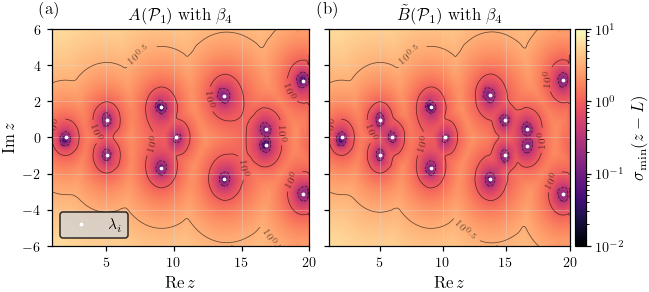

In [17]:
# Use the full text width and a height that gives each panel a roughly square aspect ratio
fig_height = fig_width * 0.45 

with matplotlib.rc_context(PS_RC):
    fig, axes = plt.subplots(1, 2, figsize=(fig_width, fig_height), sharey=True)
    
    # White markers contrast perfectly against the dark valleys of the magma colormap
    marker_style = {"color": "white", "markersize": 3} 
    
    # --- Left Panel: A(CG) ---
    ps.plot_pseudospectrum(
        ps2[("A(CG)", "b4")], ax=axes[0],
        cmap="magma",
        title=r"$A(\mathcal{P}_1)$ with $\beta_4$",
        xlim=PS2_WINDOW[0], ylim=PS2_WINDOW[1],
        vmin=PS2_SCALE[0], vmax=PS2_SCALE[1],
        per_decade=2, grid=True, legend=True, colorbar=False,
        legend_kw={
            "frameon": True, 
            "facecolor": "lightgray",  # Sets the legend background to grey
            "edgecolor": "black",       # Adds a slightly darker border
            "loc": "lower left", 
            "fontsize": base_fontsize - 1
        },
        eig_kw=marker_style
    )
    
    # Explicitly capitalize the legend label
    if axes[0].get_legend():
        for text in axes[0].get_legend().get_texts():
            text.set_text(r"$\lambda_i$")
            
    axes[0].text(-0.05, 1.05, "(a)", transform=axes[0].transAxes, 
                 fontsize=base_fontsize, fontweight="bold", va="bottom")
    
    # --- Right Panel: s(P1-divP1) ---
    ps.plot_pseudospectrum(
        ps2[("s(P1-divP1)", "b4")], ax=axes[1],
        cmap="magma",
        title=r"$\tilde{B}(\mathcal{P}_1)$ with $\beta_4$",
        xlim=PS2_WINDOW[0], ylim=PS2_WINDOW[1],
        vmin=PS2_SCALE[0], vmax=PS2_SCALE[1],
        per_decade=2, grid=True, legend=False,
        colorbar_label=r"$\sigma_{\min}(z - L)$",
        colorbar_kw={"pad": 0.02, "fraction": 0.045},
        eig_kw=marker_style
    )
    
    axes[1].text(-0.05, 1.05, "(b)", transform=axes[1].transAxes, 
                 fontsize=base_fontsize, fontweight="bold", va="bottom")
    
    axes[1].set_ylabel("")
    plt.tight_layout(pad=0.1)
    fig.savefig(FIGDIR / "topform_pseudo_b4_sidebyside.eps")
    plt.show()

## Figure 4.5: Genuine and spurious top-form eigenmodes under β4


$\sigma$(BDM) and $\sigma$(P1-divP1) under $\beta_4$, $R_m = 1$, $N = 100$, $p = 1$, $\tau = 1.9$,
20 eigenvalues; the spurious index is what `match` leaves unpaired against $\sigma$(BDM) on the same mesh.
Writes `topform_mode_b4_bdm_1.eps`, `topform_mode_b4_bdm_4.eps`, `topform_mode_b4_p1_spurious.eps`
($L^\infty$-normalised, `RdBu_r` over $[-1,1]$).


In [18]:
# --- Execution Block ---

N_MODE = 100
mesh_mode = crisscross_mesh(N_MODE)

good_b3 = solve_topform(form="s(BDM)", wind="b4", N=N_MODE, mesh=mesh_mode, n_eigs=20)
bad_b3 = solve_topform(form="s(P1-divP1)", wind="b4", N=N_MODE, mesh=mesh_mode, n_eigs=20)

# Isolate the shadow branch the way Section 6.2 does: by what the FEEC pair on the
# same mesh does not find.  No reference spectrum is available under advection.
_, extra_b3 = match(bad_b3.real[:12], good_b3.real, rtol=3e-3)
k_sp = int(np.argmin(np.abs(bad_b3.real - extra_b3[0])))

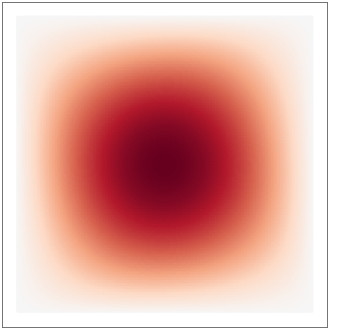

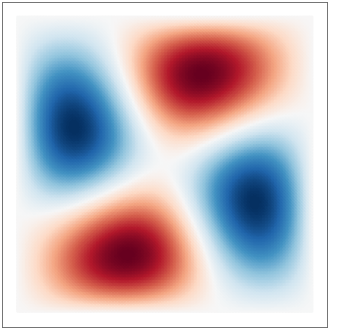

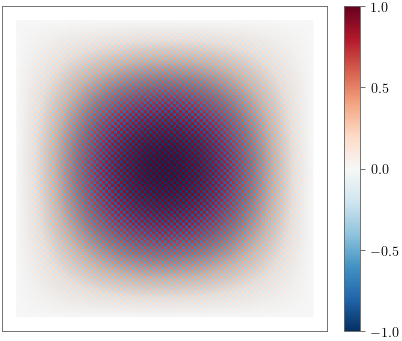

In [19]:
import matplotlib.ticker as ticker
from mpl_toolkits.axes_grid1 import make_axes_locatable
import numpy as np

def plot_mode(ax, f, title="", cmap="RdBu_r", add_colorbar=False, cbar_label=None, rasterized=True):
    """
    Plot a scalar finite element eigenmode, normalized to peak amplitude 1.
    Reserves uniform space for a colorbar to ensure identical PDF bounding boxes.
    """
    d = f.dat.data_ro
    peak = float(np.abs(d).max())
    
    if peak > 1e-13:
        sign = 1.0 if d[int(np.argmax(np.abs(d)))] > 0 else -1.0
        f.dat.data[:] = sign * d / peak

    lim = 1.0 
    art = tripcolor(f, axes=ax, cmap=cmap, vmin=-lim, vmax=lim, rasterized=rasterized)
    
    ax.set_aspect("equal")
    ax.set_xticks([])
    ax.set_yticks([])
    
    if title:
        ax.set_title(title, fontsize=base_fontsize - 1, pad=10)
    
    for spine in ax.spines.values():
        spine.set_linewidth(0.6)
        spine.set_color("dimgray")
        
    # --- Uniform Colorbar Space Allocation ---
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="5%", pad=0.15)
    
    if add_colorbar:
        fig = ax.figure
        cbar = fig.colorbar(art, cax=cax)
        
        cbar.outline.set_linewidth(0.6)
        cbar.outline.set_color("dimgray")
        cbar.ax.tick_params(labelsize=base_fontsize - 2, width=0.6, color="dimgray")
        
        if cbar_label:
            cbar.set_label(cbar_label, fontsize=base_fontsize - 1)
            
        cbar.locator = ticker.LinearLocator(numticks=5)
        cbar.update_ticks()
    else:
        # Hide the axis completely
        cax.axis('off')
        # Draw an invisible line so `savefig` respects the allocated space
        cax.plot([0, 1], [0, 1], color='none')
        
    return art

# 1. Genuine lambda_1 (No colorbar)
fig, ax = plt.subplots(figsize=(4.2, 4.2))
plot_mode(ax, eigenfunction(good_b3, 0), add_colorbar=False)
fig.savefig(FIGDIR / "topform_mode_b4_bdm_1.eps", dpi=1200)
plt.show()

# 2. Genuine lambda_4 (No colorbar)
fig, ax = plt.subplots(figsize=(4.2, 4.2))
plot_mode(ax, eigenfunction(good_b3, 3), add_colorbar=False)
fig.savefig(FIGDIR / "topform_mode_b4_bdm_4.eps", dpi=1200)
plt.show()

# 3. Spurious mode (With colorbar)
fig, ax = plt.subplots(figsize=(4.2, 4.2))
plot_mode(ax, eigenfunction(bad_b3, k_sp), add_colorbar=True)
fig.savefig(FIGDIR / "topform_mode_b4_p1_spurious.eps", dpi=1200)
plt.show()

# Appendix


## Table A.1: Top-form eigenvalues with advection at Rm = 1 (β4)


All six formulations under $\beta_4$ at $R_m = 1$, $N = 64$, $p = 3$, 100 eigenvalues near $\tau = 1.9$,
first 20 shown with MUMPS COND1. Parameter re-run of the $R_m = 10$ cell (`Rm = 10` -> `Rm = 1`); the thesis
uses the $A(CG)$, $B(RT)$ and $\sigma$(P1-divP1) columns.


In [20]:
N_ADV = 64
mesh_adv = crisscross_mesh(N_ADV)

# def solve_topform(form="B(RT)", wind="b0", N=32, degree=1, Rm=1.0, n_eigs=100,
#                   nev=None, tau=None, mesh=None, L=L_DOMAIN, cond=True):

runs_b4 = {f: solve_topform(form=f, wind="b4", N=N_ADV,degree=3, Rm = 1, mesh=mesh_adv, n_eigs=100)
           for f in ALL_FORMS}

# b4 produces complex conjugate pairs. We must sort them with np.sort_complex 
# to ensure the order (a-bi, a+bi) aligns perfectly across all formulations.
def ordered(spectrum, n=20):
    return np.sort_complex(np.asarray(spectrum.values))[:n]

# There is no closed-form exact spectrum for b4, so we drop the 'exact' column 
# and let the formulations act as cross-references.
tbl = pd.DataFrame({f: ordered(runs_b4[f], 20) for f in ALL_FORMS},
                   index=[f"$\\lambda_{{{i+1}}}$" for i in range(20)])

# Append the condition number using MUMPS COND1
tbl.loc["MUMPS COND1"] = [runs_b4[f].kappa["MUMPS COND1"] for f in ALL_FORMS]

fmt_table(tbl, row_rules=[("MUMPS COND1", "{:.2e}")],
          caption=rf"$\beta_4 = (-\hat{{y}}, \hat{{x}})$, $R_m = 1$: rigid rotation. "
                  rf"No exact spectrum available; criss-cross $N={N_ADV}$")

**$\beta_4 = (-\hat{y}, \hat{x})$, $R_m = 1$: rigid rotation. No exact spectrum available; criss-cross $N=64$**

,A(CG),B(RT),B(BDM),s(RT),s(BDM),s(P1-divP1)
$\lambda_{1}$,2.003577,2.003577,2.003577,2.003577,2.003577,2.003835
$\lambda_{2}$,5.02329-0.96815i,5.02329-0.96815i,5.02329-0.96815i,5.02329-0.96815i,5.02329-0.96815i,5.02492-0.96813i
$\lambda_{3}$,5.02329+0.96815i,5.02329+0.96815i,5.02329+0.96815i,5.02329+0.96815i,5.02329+0.96815i,5.02492+0.96813i
$\lambda_{4}$,9.02516-1.68951i,9.02516-1.68951i,9.02516-1.68951i,9.02516-1.68951i,9.02516-1.68951i,6.000253
$\lambda_{5}$,9.02516+1.68951i,9.02516+1.68951i,9.02516+1.68951i,9.02516+1.68951i,9.02516+1.68951i,9.03057-1.68876i
$\lambda_{6}$,10.099276,10.099276,10.099276,10.099276,10.099276,9.03057+1.68876i
$\lambda_{7}$,13.62662-2.33299i,13.62662-2.33299i,13.62662-2.33299i,13.62662-2.33299i,13.62662-2.33299i,10.105764
$\lambda_{8}$,13.62662+2.33299i,13.62662+2.33299i,13.62662+2.33299i,13.62662+2.33299i,13.62662+2.33299i,13.63763-2.33141i
$\lambda_{9}$,16.51903-0.47297i,16.51903-0.47297i,16.51903-0.47297i,16.51903-0.47297i,16.51903-0.47297i,13.63763+2.33141i
$\lambda_{10}$,16.51903+0.47297i,16.51903+0.47297i,16.51903+0.47297i,16.51903+0.47297i,16.51903+0.47297i,14.99104-0.96067i


As-saved $p = 1$ record of the $\tilde{B}(\mathcal{P}_1)$ column: all six formulations under `b3`, `b4` at
$R_m = 1$, $N = 64$, 100 eigenvalues, with the red `!` marks (values with no counterpart in $B(BDM)$ on the same
mesh) as printed in the thesis.


In [21]:
from IPython.display import HTML

N_TBL_ADV, N_SHOW_ADV, N_EIG_ADV = 64, 15, 100
ADV_WINDS = ["b3", "b4"]

print(f"{'wind':6s} {'||beta||_inf':>13s} {'cell Pe':>9s} {'nu':>8s}   structure")
for w in ADV_WINDS:
    wd = WINDS[w]
    print(f"{w:6s} {wd.sup:13.4f} {(L_DOMAIN / N_TBL_ADV) * wd.sup / 2:9.3f} "
          f"{nu_min(wd.sup, 1.0):8.1f}   {wd.note}")

mesh_adv_tbl = crisscross_mesh(N_TBL_ADV)
runs_adv = {(f, w): solve_topform(form=f, wind=w, N=N_TBL_ADV, mesh=mesh_adv_tbl,
                                  n_eigs=N_EIG_ADV)
            for w in ADV_WINDS for f in ALL_FORMS}

#: A red mark on any computed value with no counterpart in the FEEC reference.
SPUR = ('<span style="color:#d62728;font-weight:bold" '
        'title="no counterpart in B(BDM) on the same mesh">&nbsp;!</span>')


def marked_table(wind, n=N_SHOW_ADV, rtol=3e-3):
    r"""The Section 6 table for one advective wind, spurious values marked.

    `np.sort_complex` orders by real part then imaginary part, so index $j$ means
    the same thing in every column even once the spectrum is complex.  Spurious
    entries are those `match` leaves unpaired against `B(BDM)` on the same mesh.
    `B(BDM)` is the reference, so its own column cannot carry a mark by
    construction; the other four FEEC columns are a genuine test of the rule and
    they are the reason it is worth applying to all six.

    Rendered through `to_html(escape=False)` rather than returned as a DataFrame,
    because pandas escapes markup in a cell and the mark has to be a colour.
    """
    cols = {f: np.sort_complex(np.asarray(runs_adv[(f, wind)].values))[:n]
            for f in ALL_FORMS}
    ref = runs_adv[("B(BDM)", wind)].values
    flag = {f: np.isnan(match(cols[f], ref, rtol=rtol)[0]) for f in ALL_FORMS}

    tbl = pd.DataFrame({f: list(cols[f]) for f in ALL_FORMS},
                       index=[f"$\\lambda_{{{i+1}}}$" for i in range(n)],
                       dtype=object)
    tbl.loc[r"$\kappa(A-\sigma M)$"] = [runs_adv[(f, wind)].kappa["MUMPS COND1"]
                                        for f in ALL_FORMS]
    # The row rule has to match the index label as written: a rule keyed on
    # "\kappa_1" would not match "$\kappa(A-\sigma M)$" and would fall through
    # to the default float format.
    out = fmt_table(
        tbl, default="{:.6f}", row_rules=[(r"\kappa", "{:.2e}")],
        caption=rf"**`{wind}`**: {WINDS[wind].tex}, {WINDS[wind].note}. First "
                rf"{n} computed eigenvalues out of {N_EIG_ADV}, $R_m = 1$, "
                rf"criss-cross $N = {N_TBL_ADV}$ ($h = \pi/{N_TBL_ADV}$, "
                rf"{4 * N_TBL_ADV ** 2} cells), polynomial degree $p = 1$.  The "
                r"condition number is MUMPS' COND1 estimate of the shifted pencil "
                r"$\kappa(A-\sigma M)$, $\sigma = \tau+\nu$ with $\tau = 1.9$.  "
                r"A red **!** marks a value with no counterpart in `B(BDM)` on "
                r"the same mesh.")
    for f in ALL_FORMS:
        out[f] = [v + SPUR if (j < n and flag[f][j]) else v
                  for j, v in enumerate(out[f])]
    return HTML(out.to_html(escape=False))


for w in ADV_WINDS:
    _, _extra = match(np.sort_complex(np.asarray(runs_adv[("s(P1-divP1)", w)].values))[:N_SHOW_ADV],
                      runs_adv[("B(BDM)", w)].values, rtol=3e-3)
    print(f"\n{w}: values in s(P1-divP1)'s first {N_SHOW_ADV} with no counterpart "
          f"in B(BDM): {np.round(_extra, 5)}")
    print("    marks per column: "
          + "  ".join(f"{f}={int(np.isnan(match(np.sort_complex(np.asarray(runs_adv[(f, w)].values))[:N_SHOW_ADV], runs_adv[('B(BDM)', w)].values, rtol=3e-3)[0]).sum())}"
                      for f in ALL_FORMS))

wind    ||beta||_inf   cell Pe       nu   structure
b3            2.0000     0.049     10.0   $\psi=\sin 2x\,\sin 2y$; potential, not solenoidal
b4            2.2214     0.055     11.9   rigid rotation



b3: values in s(P1-divP1)'s first 15 with no counterpart in B(BDM): [ 7.06196+0.j 15.10365+0.j 15.10365+0.j]
    marks per column: A(CG)=0  B(RT)=0  B(BDM)=0  s(RT)=0  s(BDM)=0  s(P1-divP1)=3

b4: values in s(P1-divP1)'s first 15 with no counterpart in B(BDM): [ 6.00025+0.j      14.99104-0.96067j 14.99104+0.96067j]
    marks per column: A(CG)=0  B(RT)=0  B(BDM)=0  s(RT)=0  s(BDM)=0  s(P1-divP1)=3


In [22]:
marked_table("b4")

****`b4`**: $\beta=(-\hat y,\ \hat x)$, rigid rotation. First 15 computed eigenvalues out of 100, $R_m = 1$, criss-cross $N = 64$ ($h = \pi/64$, 16384 cells), polynomial degree $p = 1$.  The condition number is MUMPS' COND1 estimate of the shifted pencil $\kappa(A-\sigma M)$, $\sigma = \tau+\nu$ with $\tau = 1.9$.  A red **!** marks a value with no counterpart in `B(BDM)` on the same mesh.**

,A(CG),B(RT),B(BDM),s(RT),s(BDM),s(P1-divP1)
$\lambda_{1}$,2.003895,2.003441,2.003835,2.003441,2.003835,2.003835
$\lambda_{2}$,5.02576-0.96813i,5.02290-0.96783i,5.02492-0.96813i,5.02290-0.96783i,5.02492-0.96813i,5.02492-0.96813i
$\lambda_{3}$,5.02576+0.96813i,5.02290+0.96783i,5.02492+0.96813i,5.02290+0.96783i,5.02492+0.96813i,5.02492+0.96813i
$\lambda_{4}$,9.03350-1.68760i,9.02401-1.68764i,9.03057-1.68876i,9.02401-1.68764i,9.03057-1.68876i,6.000253 !
$\lambda_{5}$,9.03350+1.68760i,9.02401+1.68764i,9.03057+1.68876i,9.02401+1.68764i,9.03057+1.68876i,9.03057-1.68876i
$\lambda_{6}$,10.110525,10.099152,10.105765,10.099152,10.105765,9.03057+1.68876i
$\lambda_{7}$,13.64130-2.32914i,13.62141-2.32929i,13.63763-2.33141i,13.62141-2.32929i,13.63763-2.33141i,10.105764
$\lambda_{8}$,13.64130+2.32914i,13.62141+2.32929i,13.63763+2.33141i,13.62141+2.32929i,13.63763+2.33141i,13.63763-2.33141i
$\lambda_{9}$,16.55439-0.46924i,16.52143-0.47086i,16.53816-0.47150i,16.52143-0.47086i,16.53816-0.47150i,13.63763+2.33141i
$\lambda_{10}$,16.55439+0.46924i,16.52143+0.47086i,16.53816+0.47150i,16.52143+0.47086i,16.53816+0.47150i,14.99104-0.96067i !


## Table A.2: First 15 of 100 computed top-form eigenvalues for β0 across six formulations


$\beta = 0$, $R_m = 1$, $N = 64$, 100 eigenvalues near $\tau = 1.9$, all six formulations; solver diagnostics,
then the first 15 eigenvalues against the exact $m^2+n^2$ with the MUMPS COND1 row. Parameter re-run of the
solve cell (`degree =3` -> `degree =1`): the thesis numbers are the $p = 1$ values (see Notes).


In [23]:
runs0 = {f: solve_topform(form=f, wind="b0", N=N_BASE, mesh=mesh, n_eigs=N_EIGS, degree =1)
         for f in ALL_FORMS}

diag = pd.DataFrame([
    dict(formulation=f, pencil=s.size, nu=0,
         sigma=s.meta["tau"], converged=s.meta["nconv"],
         reason=s.meta["reason"], **{r"$\lambda_{\max}$": s.real.max()},
         **{k: v for k, v in s.kappa.items() if k != "INFOG(1)"})
    for f, s in runs0.items()]).set_index("formulation")
fmt_table(diag, default="{:.3e}",
          rules=[("pencil", "{:.0f}"), ("converged", "{:.0f}"), ("reason", "{:.0f}"),
                 ("nu", "{:.1f}"), ("sigma", "{:.2f}"), ("lambda", "{:.2f}")],
          caption=rf"Solver diagnostics at $N={N_BASE}$, $\beta=0$. $\sigma=\tau+\nu$ is "
                  r"the shift actually handed to MUMPS; `reason` $=1$ is SLEPc's "
                  r"converged flag.")

**Solver diagnostics at $N=64$, $\beta=0$. $\sigma=\tau+\nu$ is the shift actually handed to MUMPS; `reason` $=1$ is SLEPc's converged flag.**

,pencil,nu,sigma,converged,reason,$\lambda_{\max}$,MUMPS COND1,Hager $\kappa_1$
formulation,,,,,,,,
A(CG),8321,0.0,1.90,143,1,146.79,6.662e+04,1.066e+05
B(RT),41088,0.0,1.90,142,1,144.31,2.712e+03,1.352e+05
B(BDM),65792,0.0,1.90,146,1,146.40,2.702e+03,1.991e+05
s(RT),41088,0.0,1.90,142,1,144.31,2.712e+03,1.352e+05
s(BDM),65792,0.0,1.90,146,1,146.40,2.702e+03,1.991e+05
s(P1-divP1),28930,0.0,1.90,128,1,109.79,1.152e+03,9.947e+03


In [24]:
n = 15

ex10 = exact_spectrum(n)

tbl = pd.DataFrame(
    {"exact": ex10} | {f: runs0[f].real[:n] for f in ALL_FORMS}, 
    index=[f"$\\lambda_{{{i+1}}}$" for i in range(n)]
)

# every results table in this notebook closes with the conditioning of the matrix
# that produced it
tbl.loc[r"$\kappa(A-\sigma M)$"] = [np.nan] + [runs0[f].kappa['MUMPS COND1'] for f in ALL_FORMS]

fmt_table(
    tbl, 
    row_rules=[(r"\kappa_1", "{:.2e}")], 
    caption=r"First ten eigenvalues, $\beta = 0$, $R_m = 1$, " 
            rf"criss-cross $N = {N_BASE}$, lowest order"
)

**First ten eigenvalues, $\beta = 0$, $R_m = 1$, criss-cross $N = 64$, lowest order**

,exact,A(CG),B(RT),B(BDM),s(RT),s(BDM),s(P1-divP1)
$\lambda_{1}$,2.000000,2.000335,1.999866,2.000268,1.999866,2.000268,2.000268
$\lambda_{2}$,5.000000,5.002544,4.999615,5.001673,4.999615,5.001673,5.001673
$\lambda_{3}$,5.000000,5.002544,4.999615,5.001673,4.999615,5.001673,5.001673
$\lambda_{4}$,8.000000,8.005357,7.997858,8.004284,7.997858,8.004284,5.998795
$\lambda_{5}$,10.000000,10.011584,9.999865,10.006693,9.999865,10.006693,8.004283
$\lambda_{6}$,10.000000,10.011584,9.999865,10.006693,9.999865,10.006693,10.006692
$\lambda_{7}$,13.000000,13.015405,12.995598,13.011312,12.995598,13.011312,10.006692
$\lambda_{8}$,13.000000,13.015405,12.995598,13.011312,12.995598,13.011312,13.011310
$\lambda_{9}$,17.000000,17.035498,17.001616,17.019340,17.001616,17.019340,13.011310
$\lambda_{10}$,17.000000,17.035498,17.001616,17.019340,17.001616,17.019340,14.981671


## Table A.3: Top-form eigenvalues under β2 and β4 at Rm = 10


$\beta_4$ then $\beta_2$ at $R_m = 10$, $N = 64$, $p = 3$, 100 eigenvalues near $\tau = 1.9$ (first 20 shown,
MUMPS COND1 row). Verbatim cells with the stored outputs that the thesis table was typed from.


In [25]:
N_ADV = 64
mesh_adv = crisscross_mesh(N_ADV)

# def solve_topform(form="B(RT)", wind="b0", N=32, degree=1, Rm=1.0, n_eigs=100,
#                   nev=None, tau=None, mesh=None, L=L_DOMAIN, cond=True):

runs_b4 = {f: solve_topform(form=f, wind="b4", N=N_ADV,degree=3, Rm = 10, mesh=mesh_adv, n_eigs=100)
           for f in ALL_FORMS}

# b4 produces complex conjugate pairs. We must sort them with np.sort_complex 
# to ensure the order (a-bi, a+bi) aligns perfectly across all formulations.
def ordered(spectrum, n=20):
    return np.sort_complex(np.asarray(spectrum.values))[:n]

# There is no closed-form exact spectrum for b4, so we drop the 'exact' column 
# and let the formulations act as cross-references.
tbl = pd.DataFrame({f: ordered(runs_b4[f], 20) for f in ALL_FORMS},
                   index=[f"$\\lambda_{{{i+1}}}$" for i in range(20)])

# Append the condition number using MUMPS COND1
tbl.loc["MUMPS COND1"] = [runs_b4[f].kappa["MUMPS COND1"] for f in ALL_FORMS]

fmt_table(tbl, row_rules=[("MUMPS COND1", "{:.2e}")],
          caption=rf"$\beta_4 = (-\hat{{y}}, \hat{{x}})$, $R_m = 1$: rigid rotation. "
                  rf"No exact spectrum available; criss-cross $N={N_ADV}$")

**$\beta_4 = (-\hat{y}, \hat{x})$, $R_m = 1$: rigid rotation. No exact spectrum available; criss-cross $N=64$**

,A(CG),B(RT),B(BDM),s(RT),s(BDM),s(P1-divP1)
$\lambda_{1}$,0.208143,0.208143,0.208143,0.208143,0.208143,0.208156
$\lambda_{2}$,0.52744-0.99881i,0.52744-0.99881i,0.52744-0.99881i,0.52744-0.99881i,0.52744-0.99881i,0.52758-0.99880i
$\lambda_{3}$,0.52744+0.99881i,0.52744+0.99881i,0.52744+0.99881i,0.52744+0.99881i,0.52744+0.99881i,0.52758+0.99880i
$\lambda_{4}$,0.94574-1.99546i,0.94574-1.99546i,0.94574-1.99546i,0.94574-1.99546i,0.94574-1.99546i,0.610106
$\lambda_{5}$,0.94574+1.99546i,0.94574+1.99546i,0.94574+1.99546i,0.94574+1.99546i,0.94574+1.99546i,0.94623-1.99544i
$\lambda_{6}$,1.090128,1.090128,1.090128,1.090128,1.090128,0.94623+1.99544i
$\lambda_{7}$,1.45705-2.98892i,1.45705-2.98892i,1.45705-2.98892i,1.45705-2.98892i,1.45705-2.98892i,1.090797
$\lambda_{8}$,1.45705+2.98892i,1.45705+2.98892i,1.45705+2.98892i,1.45705+2.98892i,1.45705+2.98892i,1.45829-2.98886i
$\lambda_{9}$,1.75367-0.99513i,1.75367-0.99513i,1.75367-0.99513i,1.75367-0.99513i,1.75367-0.99513i,1.45829+2.98886i
$\lambda_{10}$,1.75367+0.99513i,1.75367+0.99513i,1.75367+0.99513i,1.75367+0.99513i,1.75367+0.99513i,1.53998-0.98881i


In [26]:
N_ADV = 64
mesh_adv = crisscross_mesh(N_ADV)

# For b2 (linear strain), we use the default shift (tau = 1.9).
# Because b2 is a gradient field, King's theorem guarantees a real spectrum.
runs_b2 = {f: solve_topform(form=f, wind="b2", N=N_ADV,degree=3, Rm = 10, mesh=mesh_adv, n_eigs=100)
           for f in ALL_FORMS}

# Since b2's spectrum is real to machine precision, standard sorting or 
# np.sort_complex will both work perfectly to align the formulations.
def ordered(spectrum, n=20):
    return np.sort_complex(np.asarray(spectrum.values))[:n]

# There is no closed-form exact spectrum for b2, so we rely on the FEEC columns
# to act as the reference.
tbl = pd.DataFrame({f: ordered(runs_b2[f], 20) for f in ALL_FORMS},
                   index=[f"$\\lambda_{{{i+1}}}$" for i in range(20)])

# Append the condition number using MUMPS COND1
tbl.loc["MUMPS COND1"] = [runs_b2[f].kappa["MUMPS COND1"] for f in ALL_FORMS]

fmt_table(tbl, row_rules=[("MUMPS COND1", "{:.2e}")],
          caption=rf"$\beta_2 = (x, -y)$, $R_m = 1$: linear strain. "
                  rf"No exact spectrum available; criss-cross $N={N_ADV}$")

**$\beta_2 = (x, -y)$, $R_m = 1$: linear strain. No exact spectrum available; criss-cross $N=64$**

,A(CG),B(RT),B(BDM),s(RT),s(BDM),s(P1-divP1)
$\lambda_{1}$,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000
$\lambda_{2}$,5.000000,5.000000,5.000000,5.000000,5.000000,3.000944
$\lambda_{3}$,5.000000,5.000000,5.000000,5.000000,5.000000,5.00000-0.00000i
$\lambda_{4}$,7.000000,7.00000-0.00000i,7.000000,7.000000,7.000000,5.00000+0.00000i
$\lambda_{5}$,7.000000,7.00000+0.00000i,7.000000,7.000000,7.00000-0.00000i,5.001879
$\lambda_{6}$,7.000000,7.000000,7.000000,7.000000,7.00000+0.00000i,5.009865
$\lambda_{7}$,9.000000,9.000000,8.999999,9.000000,9.00000-0.00000i,6.999962
$\lambda_{8}$,9.000000,9.000000,9.000000,9.000000,9.00000+0.00000i,7.00002-0.00003i
$\lambda_{9}$,9.000000,9.000000,9.000000,9.00000-0.00000i,9.00000-0.00000i,7.00002+0.00003i
$\lambda_{10}$,9.000000,9.000000,9.000000,9.00000+0.00000i,9.00000+0.00000i,7.003110


## Table A.4: Top-form eigenvalues under β2 and β4 at Rm = 100


$\beta_4$ then $\beta_2$ at $R_m = 100$, $N = 64$, $p = 3$, 100 eigenvalues near $\tau = 1.9$ (first 20 shown,
MUMPS COND1 row).


In [27]:
N_ADV = 64
mesh_adv = crisscross_mesh(N_ADV)

# def solve_topform(form="B(RT)", wind="b0", N=32, degree=1, Rm=1.0, n_eigs=100,
#                   nev=None, tau=None, mesh=None, L=L_DOMAIN, cond=True):

runs_b4 = {f: solve_topform(form=f, wind="b4", N=N_ADV,degree=3, Rm = 100, mesh=mesh_adv, n_eigs=100)
           for f in ALL_FORMS}

# b4 produces complex conjugate pairs. We must sort them with np.sort_complex 
# to ensure the order (a-bi, a+bi) aligns perfectly across all formulations.
def ordered(spectrum, n=20):
    return np.sort_complex(np.asarray(spectrum.values))[:n]

# There is no closed-form exact spectrum for b4, so we drop the 'exact' column 
# and let the formulations act as cross-references.
tbl = pd.DataFrame({f: ordered(runs_b4[f], 20) for f in ALL_FORMS},
                   index=[f"$\\lambda_{{{i+1}}}$" for i in range(20)])

# Append the condition number using MUMPS COND1
tbl.loc["MUMPS COND1"] = [runs_b4[f].kappa["MUMPS COND1"] for f in ALL_FORMS]

fmt_table(tbl, row_rules=[("MUMPS COND1", "{:.2e}")],
          caption=rf"$\beta_4 = (-\hat{{y}}, \hat{{x}})$, $R_m = 1$: rigid rotation. "
                  rf"No exact spectrum available; criss-cross $N={N_ADV}$")

**$\beta_4 = (-\hat{y}, \hat{x})$, $R_m = 1$: rigid rotation. No exact spectrum available; criss-cross $N=64$**

,A(CG),B(RT),B(BDM),s(RT),s(BDM),s(P1-divP1)
$\lambda_{1}$,0.022051,0.022051,0.022051,0.022051,0.022051,0.022041
$\lambda_{2}$,0.05597-0.99999i,0.05597-0.99999i,0.05597-0.99999i,0.05597-0.99999i,0.05597-0.99999i,0.05596-0.99999i
$\lambda_{3}$,0.05597+0.99999i,0.05597+0.99999i,0.05597+0.99999i,0.05597+0.99999i,0.05597+0.99999i,0.05596+0.99999i
$\lambda_{4}$,0.10054-1.99997i,0.10054-1.99997i,0.10054-1.99997i,0.10054-1.99997i,0.10054-1.99997i,0.076880
$\lambda_{5}$,0.10054+1.99997i,0.10054+1.99997i,0.10054+1.99997i,0.10054+1.99997i,0.10054+1.99997i,0.10054-1.99997i
$\lambda_{6}$,0.116135,0.116135,0.116135,0.116135,0.116135,0.10054+1.99997i
$\lambda_{7}$,0.15514-2.99992i,0.15514-2.99992i,0.15514-2.99992i,0.15514-2.99992i,0.15514-2.99992i,0.116152
$\lambda_{8}$,0.15514+2.99992i,0.15514+2.99992i,0.15514+2.99992i,0.15514+2.99992i,0.15514+2.99992i,0.15520-2.99992i
$\lambda_{9}$,0.18753-0.99997i,0.18753-0.99997i,0.18753-0.99997i,0.18753-0.99997i,0.18753-0.99997i,0.15520+2.99992i
$\lambda_{10}$,0.18753+0.99997i,0.18753+0.99997i,0.18753+0.99997i,0.18753+0.99997i,0.18753+0.99997i,0.18764-0.99997i


In [28]:
N_ADV = 64
mesh_adv = crisscross_mesh(N_ADV)

# For b2 (linear strain), we use the default shift (tau = 1.9).
# Because b2 is a gradient field, King's theorem guarantees a real spectrum.
runs_b2 = {f: solve_topform(form=f, wind="b2", N=N_ADV,degree=3, Rm = 100, mesh=mesh_adv, n_eigs=100)
           for f in ALL_FORMS}

# Since b2's spectrum is real to machine precision, standard sorting or 
# np.sort_complex will both work perfectly to align the formulations.
def ordered(spectrum, n=20):
    return np.sort_complex(np.asarray(spectrum.values))[:n]

# There is no closed-form exact spectrum for b2, so we rely on the FEEC columns
# to act as the reference.
tbl = pd.DataFrame({f: ordered(runs_b2[f], 20) for f in ALL_FORMS},
                   index=[f"$\\lambda_{{{i+1}}}$" for i in range(20)])

# Append the condition number using MUMPS COND1
tbl.loc["MUMPS COND1"] = [runs_b2[f].kappa["MUMPS COND1"] for f in ALL_FORMS]

fmt_table(tbl, row_rules=[("MUMPS COND1", "{:.2e}")],
          caption=rf"$\beta_2 = (x, -y)$, $R_m = 1$: linear strain. "
                  rf"No exact spectrum available; criss-cross $N={N_ADV}$")

**$\beta_2 = (x, -y)$, $R_m = 1$: linear strain. No exact spectrum available; criss-cross $N=64$**

,A(CG),B(RT),B(BDM),s(RT),s(BDM),s(P1-divP1)
$\lambda_{1}$,3.000000,3.000000,3.000000,3.000000,3.000000,2.999726
$\lambda_{2}$,5.000000,5.000000,5.000000,5.000000,5.000000,3.000054
$\lambda_{3}$,5.000000,5.000000,5.000000,5.000000,5.000000,4.976985
$\lambda_{4}$,7.000000,7.000001,7.000000,6.999998,6.999913,4.999646
$\lambda_{5}$,7.000000,7.00001-0.00000i,7.00001-0.00002i,7.000003,7.00000-0.00000i,5.000751
$\lambda_{6}$,7.000000,7.00001+0.00000i,7.00001+0.00002i,7.000029,7.00000+0.00000i,5.055018
$\lambda_{7}$,9.000000,8.995655,8.996708,8.996917,8.999931,6.910870
$\lambda_{8}$,9.00000-0.00000i,8.999423,8.999882,8.998624,9.001860,6.97949-0.00361i
$\lambda_{9}$,9.00000+0.00000i,8.999771,9.00644-0.00510i,9.000032,9.007442,6.97949+0.00361i
$\lambda_{10}$,9.000014,9.000051,9.00644+0.00510i,9.000352,9.017610,7.00929-0.01417i


## Notes

**Parameter re-runs**
- Table 4.4: `TopForm_Spectral_Benchmark[83]` with `Rm = 10` -> `Rm = 1`. Table A.1: `[82]` with `Rm = 10` -> `Rm = 1`.
  The saved cells carry the $R_m = 10$ outputs (Table A.3) but their captions still read $R_m = 1$, i.e. they were run at
  $R_m = 1$ for Tables 4.4/A.1 and then edited; cells 84/85 are the same cells at $R_m = 100$ (Table A.4).
  The $\tilde{B}(\mathcal{P}_1)$ column and $\kappa = 1.26\times10^3$ of Table A.1 are confirmed by the stored output of
  the $p = 1$ marked table (cell 151); the $\tilde{B}(\mathcal{P}_1)$ column of Table 4.4 (3.269367, 6.440141, 6.440912,
  6.459349) is confirmed by the stored `winf_table("b2")` output of source cell 138 (not included).
- Table A.2: `[34]` with `degree =3` -> `degree =1`. The saved cell was last run at $p = 3$ (pencil 74113, COND1 1.14e6) and
  cell 36 has no stored output; the thesis numbers (2.000335, 1.999866, 2.000268; spurious 5.998795, 14.981671;
  COND1 6.66e4) are the $p = 1$ run, as the stored outputs of source cells 57, 154 and 156 show.

**Caveats (code vs. thesis captions; reported, not fixed)**
- Table A.2 caption says $p = 3$; the column headers and the numbers are $p = 1$. The thesis table has 15 values per
  column (its 18 rows include the three `!` alignment rows); cell 36 prints $n = 15$.
- Tables A.3/A.4 captions say "1-forms" and $p = 3$ with $\mathcal{P}_1/\mathcal{N}^{\mathrm{I}}_1$ headers; the cells are
  top forms with `degree=3` for $A(CG)$ and $B(RT)$.
- Figure 4.3 caption says $N \in \{4,8,16,24,32\}$; cell 88 uses `LEVELS = (8, 12, 16, 24, 32, 40)`. The caption's
  eigenfunction reference is $\tilde{B}(\mathcal{N}^{\mathrm{II}}_2)$; the code uses `B(BDM)` degree 2 (unshifted), and
  the spurious eigenfunctions are compared with `B(BDM)` at $R_m = 1/3$.
- Figure 4.4 caption says 60 eigenvalues; cell 106 uses `PS2_NEV = 200`.
- Cell 110 (Figure 4.4) rebinds the global `fig_height`; cell 108 sets `plt.rcParams` globally (`text.usetex = True`).
- Cell 88 redefines `crisscross_blocks` (identical body, default `L=np.pi`), `macro_sign` and `unsign`; cell 124 redefines
  `plot_mode`. These shadow the setup definitions exactly as in the source notebook.

**Dropped**
- Source cell 87 (draft $\beta_4$ convergence tables): uses `conv_fun_b4`, which no saved cell defines before it, and its
  `rate_frame` expects a `MUMPS COND1` column that `convergence_study_b4` (cell 145) does not produce; cannot run as saved
  and no thesis item uses it. Cell 88 only needs `subspace_error` (cell 38) and `cluster_modes`/`eigenpair_parts` (cell 144).
- Cells 40-54, 145-147 (convergence tables/plots for $\beta = 0$ and $\beta_4$): `CONV_FORMS`, `conv_eig`, `conv_fun` are
  only defined in the commented-out block of cell 38; not in the thesis.
- Cells 3-5, 9-15, 22-24 (mesh, wind and checkerboard pictures, construction checks), 57-79 ($\beta = 0$ spurious-branch
  study, `.pdf` figures), 90-103, 109, 111-118 (Heaviside-shear sweep, other pseudospectrum panels and resolvent tables),
  121-122 (superseded $N = 200$/`b3` mode solve and unused `plot_vector_mode`), 126-141 (envelope, $3\varepsilon$ law,
  $W^{1,\infty}$ tables), 150 (`marked_table("b3")`), 154-157 (summary tallies): not needed by any thesis item.
- Cell 8 (`sample_grid`) is only used by the dropped quiver plots.
